In [1]:
import numpy as np
import geopandas as gpd

In [2]:
df = gpd.read_file('../output/Arkansas/Arkansas_precincts_topo.topojson')

In [3]:
df.head()

,id,GEOID,precinct,total_population,black_percentage,latino_percentage,other_percentage,geometry
0,0,05001-81 - Stuttgart 2,05001-81 - Stuttgart 2,2043,27.263828,2.985805,0.342633,"MULTIPOLYGON (((-91.52312 34.47879, -91.52342 ..."
1,1,05001-36 - Gillett Ward 3,05001-36 - Gillett Ward 3,94,10.638298,1.063830,2.127660,"POLYGON ((-91.38939 34.11621, -91.38765 34.116..."
2,2,05001-53 - Dewitt 2,05001-53 - Dewitt 2,554,18.592058,1.083032,0.902527,"POLYGON ((-91.32907 34.28235, -91.3327 34.2822..."
3,3,05001-51 - DeWitt 1,05001-51 - DeWitt 1,247,26.720648,0.000000,1.214575,"POLYGON ((-91.32907 34.28235, -91.32907 34.282..."
4,4,05001-55 - Dewitt 3,05001-55 - Dewitt 3,726,18.457300,0.964187,0.826446,"POLYGON ((-91.34061 34.30203, -91.34061 34.300..."


0.0      0.000000
0.1      0.000000
0.2      0.000000
0.3      0.437956
0.4      1.215805
0.5      2.869440
0.6      5.955335
0.7     14.400000
0.8     25.000000
0.9     43.743199
1.0    100.000000
Name: black_percentage, dtype: float64


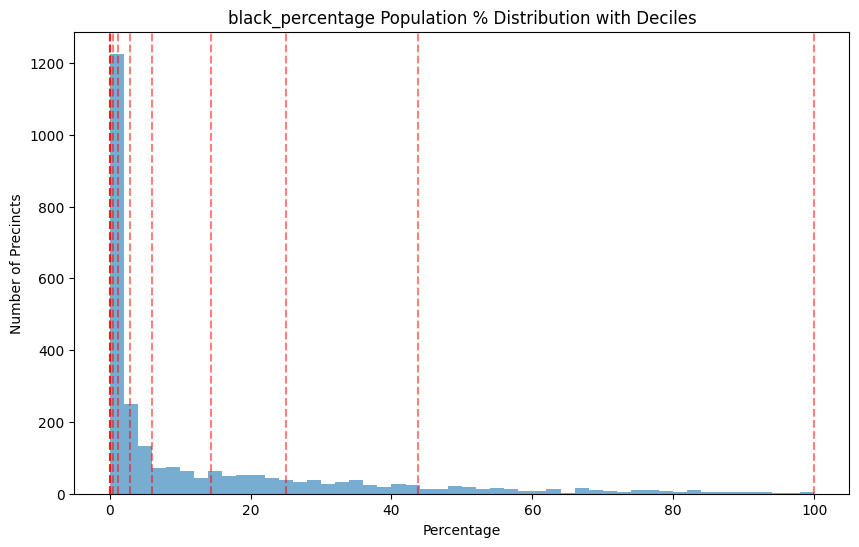

0.0     0.000000
0.1     0.000000
0.2     0.704225
0.3     1.360544
0.4     2.029221
0.5     2.739726
0.6     3.550974
0.7     4.715530
0.8     6.521739
0.9     9.713376
1.0    52.941176
Name: latino_percentage, dtype: float64


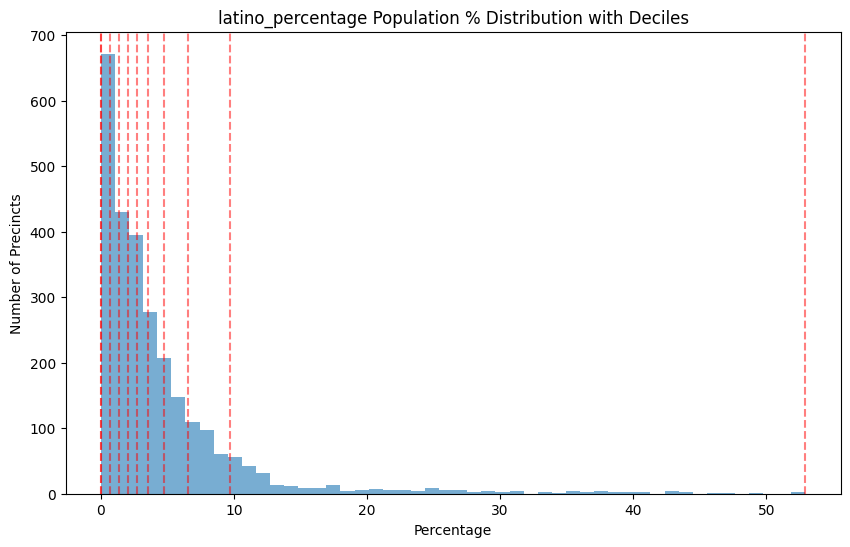

0.0     0.000000
0.1     0.555556
0.2     1.570167
0.3     2.152721
0.4     2.777778
0.5     3.324468
0.6     3.975799
0.7     4.831933
0.8     5.873379
0.9     7.936508
1.0    25.000000
Name: other_percentage, dtype: float64


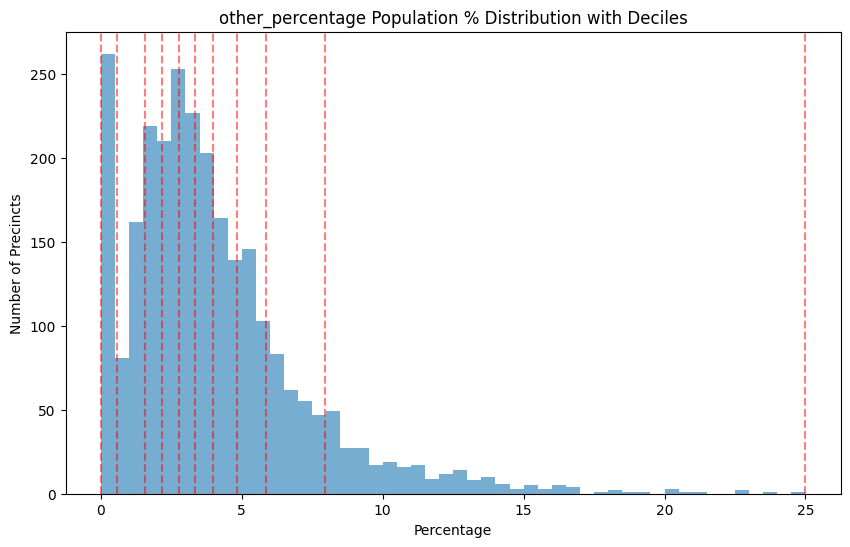

In [4]:
import matplotlib.pyplot as plt

races = ['black_percentage', 'latino_percentage', 'other_percentage']
for col in races:
    values = df[col]
    if values.isna().sum() > 0:
        print(f"{col} has nan")
    deciles = df[col].quantile(np.linspace(0, 1, 11))
    print(deciles)

    plt.figure(figsize=(10,6))

    plt.hist(values, bins=50, alpha=0.6)

    # draw vertical lines for deciles
    for d in deciles:
        plt.axvline(d, color="red", linestyle="--", alpha=0.5)

    plt.title(f"{col} Population % Distribution with Deciles")
    plt.xlabel("Percentage")
    plt.ylabel("Number of Precincts")
    plt.show()

In [5]:
import mapclassify
races = ['black', 'latino', 'other']
legend = {}
for race in races:
    values = df[f"{race}_percentage"]
    classifier = mapclassify.Quantiles(values, k=6)
    df[f"{race}_bin"] = classifier.yb
    legend[race] = {
        "bins": classifier.bins.tolist(),
        "min": float(values.min()),
        "max": float(values.max())
    }
    print(f"{race} bins: {classifier.bins}")
    
legend


black bins: [  0.           0.64516129   2.86944046  10.99404605  30.18171192
 100.        ]
latino bins: [ 0.42017177  1.55219259  2.73972603  4.29283376  7.35717711 52.94117647]
other bins: [ 1.32919857  2.3510979   3.32446809  4.52716355  6.34628634 25.        ]


{'black': {'bins': [0.0,
   0.6451612903225806,
   2.8694404591104736,
   10.994046045592441,
   30.181711917538937,
   100.0],
  'min': 0.0,
  'max': 100.0},
 'latino': {'bins': [0.4201717683329665,
   1.5521925887548123,
   2.73972602739726,
   4.292833763713221,
   7.357177108652886,
   52.94117647058824],
  'min': 0.0,
  'max': 52.94117647058824},
 'other': {'bins': [1.3291985721416935,
   2.351097900970024,
   3.324468085106383,
   4.527163550470988,
   6.346286344219383,
   25.0],
  'min': 0.0,
  'max': 25.0}}

In [6]:
import json
with open("../output/Arkansas/Arkansas_legend.json", "w") as f:
    json.dump(legend, f)

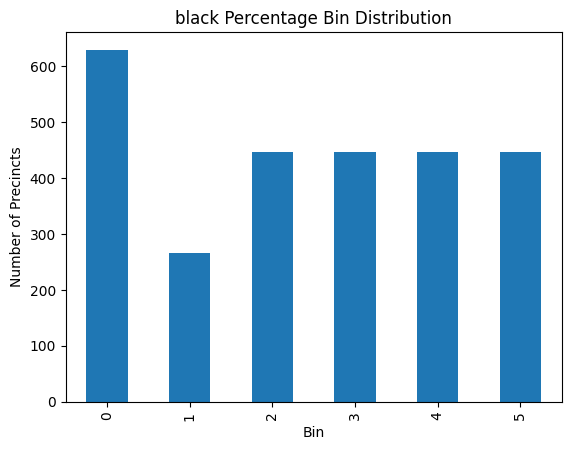

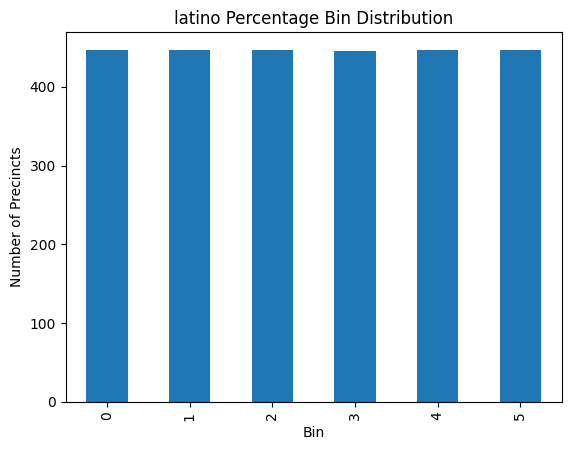

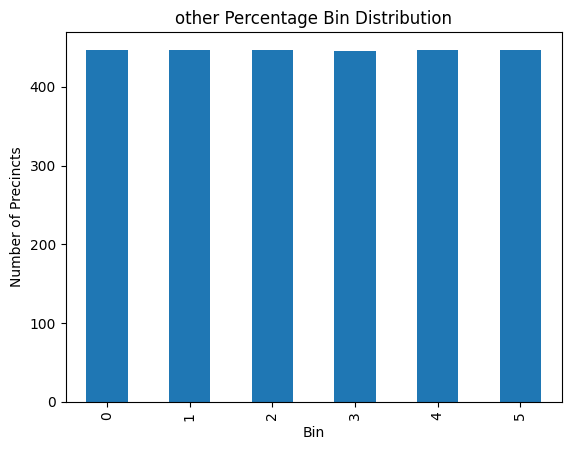

In [7]:
for race in races:
    df[f"{race}_bin"].value_counts().sort_index().plot(kind="bar")

    plt.title(f"{race} Percentage Bin Distribution")
    plt.xlabel("Bin")
    plt.ylabel("Number of Precincts")
    plt.show()

In [8]:
df['precinct'] = 'Precinct ' + df['precinct']
df.head()

,id,GEOID,precinct,total_population,black_percentage,latino_percentage,other_percentage,geometry,black_bin,latino_bin,other_bin
0,0,05001-81 - Stuttgart 2,Precinct 05001-81 - Stuttgart 2,2043,27.263828,2.985805,0.342633,"MULTIPOLYGON (((-91.52312 34.47879, -91.52342 ...",4,3,0
1,1,05001-36 - Gillett Ward 3,Precinct 05001-36 - Gillett Ward 3,94,10.638298,1.063830,2.127660,"POLYGON ((-91.38939 34.11621, -91.38765 34.116...",3,1,1
2,2,05001-53 - Dewitt 2,Precinct 05001-53 - Dewitt 2,554,18.592058,1.083032,0.902527,"POLYGON ((-91.32907 34.28235, -91.3327 34.2822...",4,1,0
3,3,05001-51 - DeWitt 1,Precinct 05001-51 - DeWitt 1,247,26.720648,0.000000,1.214575,"POLYGON ((-91.32907 34.28235, -91.32907 34.282...",4,0,0
4,4,05001-55 - Dewitt 3,Precinct 05001-55 - Dewitt 3,726,18.457300,0.964187,0.826446,"POLYGON ((-91.34061 34.30203, -91.34061 34.300...",4,1,0


In [9]:
import topojson as tp
topo = tp.Topology(df, prequantize=True)
topo.to_json("../output/Arkansas/Arkansas_precincts_topo.topojson")